In [4]:
import numpy as np
import matplotlib.pyplot as plt


S=100
K=100
r=0.03
sigma=0.2
T=1
VBS= 9.4134
R= 100

# CREATING ALL FUNCTIONS

# Simulated stock price at maturity T 
def stockprice(Z, S, r, sigma, T):
    return S* np.exp((r-0.5*sigma**2)*T+sigma*np.sqrt(T)*Z)

# Estimated standard deviation of simulated payoffs 
def standarddeviation(ST,K): 
    return np.std(np.maximum(ST-K,0))

# Estimated option price today using Monte Carlo
def mcestimator(ST, r, T, K, n):
    return np.exp(-r*T)*(1/n)*np.sum(np.maximum(ST-K,0))


# Standard error of the Monte Carlo Estimator 
def standarderror(r, T, sigmahat, n):
    return np.exp(-r*T)*(1/np.sqrt(n))*sigmahat 


def payoff(S,K): 
        return np.maximum(S-K,0)

# Standard deviation of the antithetic pair mean

def standarddeviationav(Yval): 
    return np.std(Yval)


Empirical coverage:  [[0.93]
 [0.97]
 [0.96]
 [0.94]
 [0.98]
 [0.98]
 [0.95]
 [0.91]]


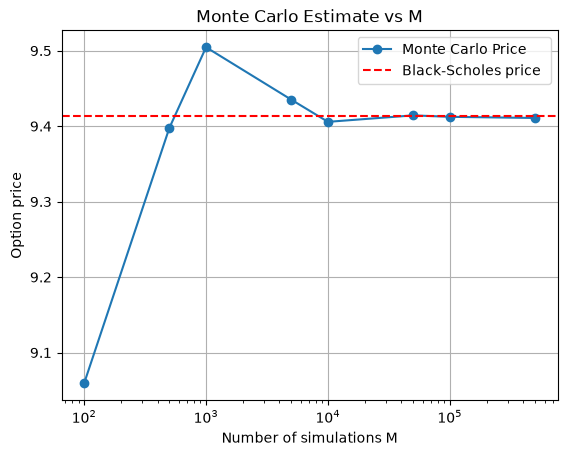

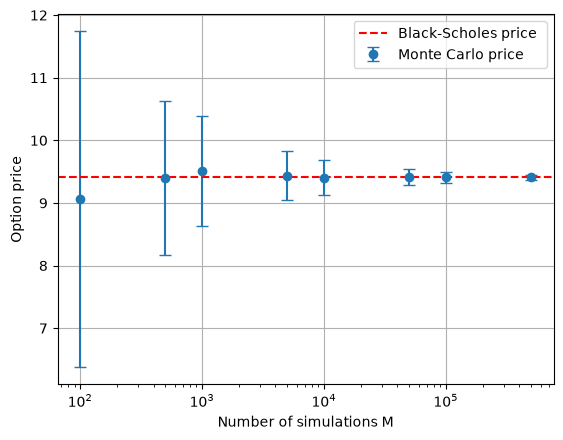

beta= 0.49022468149529697
a= 2.5292862658381554


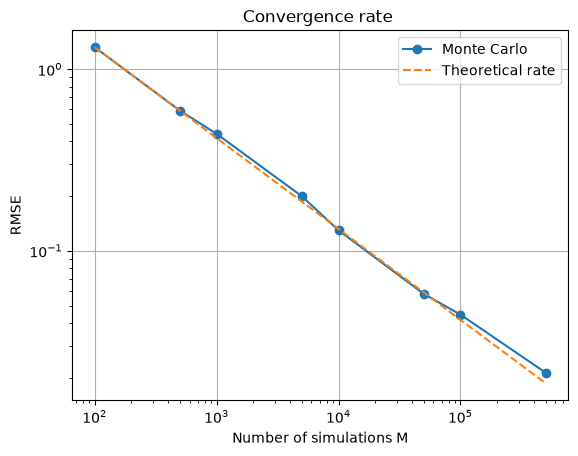

In [5]:
# CONVERGENCE STUDY 

M= [100, 500, 1000, 5000, 10000, 50000, 100000, 500000]
VMvalues= np.zeros((len(M),R))
SDvalues= np.zeros((len(M),R))
confintvalues= np.zeros((len(M),R))
inconfint= np.zeros((len(M),1))
notinconfint= np.zeros((len(M),1))
np.random.seed(0)

for i in range(len(M)):
     
     n=M[i]
     for j in range(R):
       
        Z = np.random.randn(n) 
        ST= stockprice(Z, S, r, sigma, T)

        sigmahat= standarddeviation(ST,K)
        SDvalues[i,j] = sigmahat
  
        VM= mcestimator(ST, r, T, K, n) 
        VMvalues[i,j]=VM

        SE= standarderror(r, T, sigmahat, n) 
        confint= 1.96*SE
        confintvalues[i,j]=confint 

        ll= VM-1.96*SE
        ul=VM+1.96*SE 

        if VBS>= ll and VBS<=ul:
           inconfint[i]= inconfint[i]+1
           
        else:
           notinconfint[i]=notinconfint[i]+1
           
# Calculating empirical coverage           
empiricalcoverage = np.zeros((len(M),1))

for i in range(len(M)):
   x = inconfint[i]/R
   empiricalcoverage[i]= empiricalcoverage[i]+x
   
print("Empirical"+" "+"coverage: ",empiricalcoverage) 

VMmean=[]
confintmean=[]

for i in range(len(M)):

   meanvalues = np.mean(VMvalues[i,:])
   VMmean.append(meanvalues)

   meanci= np.mean(confintvalues[i,:])
   confintmean.append(meanci)

   

plt.figure()
plt.xscale('log')
plt.plot(M,VMmean,'o-', label='Monte Carlo Price')
plt.axhline(y=VBS, color='red', linestyle='--', label='Black-Scholes price ')
plt.ylabel("Option price")
plt.xlabel("Number of simulations M")
plt.title("Monte Carlo Estimate vs M")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.errorbar(M, VMmean, yerr=confintmean, fmt='o', capsize=4, label='Monte Carlo price')
plt.axhline(VBS, color='red', linestyle='--', label='Black-Scholes price ')
plt.xscale('log')
plt.xlabel('Number of simulations M')
plt.ylabel('Option price')
plt.legend()
plt.grid()
plt.show()

# Root Mean Square Error 

RMSE=[]

for i in range(len(M)):      
   RMSEvals = np.sqrt((1/R)*sum((VMvalues[i,:]-VBS)**2))
   RMSE.append(RMSEvals)

logRMSE= np.log(RMSE)
logM= np.log(M)

theorate= RMSE[0]*M[0]**(1/2)*np.array(M)**(-0.5)

z =np.polyfit(logM,logRMSE,1)
beta = -z[0]
a= z[1]
print("beta=", beta)
print("a=",a)

plt.figure()
plt.loglog(M, RMSE, 'o-', label="Monte Carlo")
plt.loglog(M, theorate, '--', label="Theoretical rate")
plt.xlabel("Number of simulations M")
plt.ylabel("RMSE")
plt.title("Convergence rate ")
plt.grid()
plt.legend()
plt.show()



M: 100
VRF: 1.9387347583402321
M: 500
VRF: 2.605078950315766
M: 1000
VRF: 2.1431779644551496
M: 5000
VRF: 1.5334224339213363
M: 10000
VRF: 1.7080144297983744
M: 50000
VRF: 1.9038708533772069
M: 100000
VRF: 1.231719514816325
M: 500000
VRF: 2.7089487304976814


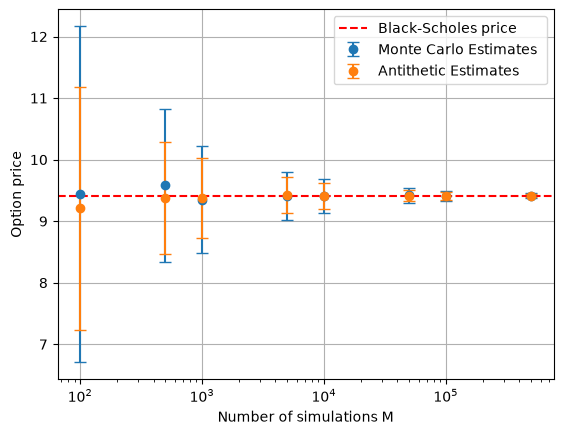

In [6]:
# ANTITHETIC VARIATES


VMavvals= np.zeros((len(M),R))
VMmcvals= np.zeros((len(M),R))
SEavvals = np.zeros((len(M), R))
SEmcvals = np.zeros((len(M), R))
confintmcvals = np.zeros((len(M), R))
confintavvals = np.zeros((len(M), R))

for i in range(len(M)):
    for j in range(R):

        Mval= M[i]//2      
        Zp = np.random.randn(Mval)
        Zn= -1*(Zp)
        Zmc= np.random.randn(M[i])
   
        STp= stockprice(Zp, S, r, sigma, T)
        STn= stockprice(Zn, S, r, sigma, T)
        STmc = stockprice(Zmc, S, r, sigma, T)

        VMmc= mcestimator(STmc, r, T, K, M[i]) 
        VMmcvals[i,j]= VMmc
        sigmamc= standarddeviation(STmc,K)
        SEmc= standarderror(r,T,sigmamc,M[i])
        SEmcvals[i,j]=SEmc 
        confintmcvals[i,j]= 1.96*SEmc
        

        hp= payoff(STp,K)
        hn= payoff(STn,K)
        Yval= (1/2)*(hp+hn)
        sigmaY = standarddeviationav(Yval)
        SEav = np.exp(-r*T) * sigmaY / np.sqrt(Mval)
        SEavvals[i,j]= SEav
        confintavvals[i,j]= 1.96*SEav
    

        VMav=np.exp(-r*T)*(1/Mval)*np.sum(Yval)
        VMavvals[i,j]= VMav 
    
    VarMC = np.var(VMmcvals[i,:])
    VarAV = np.var(VMavvals[i,:])
    VRF = VarMC/ VarAV
    print("M:", M[i])
    print("VRF:", VRF)

meanmc =[]
meanav= []
meanconfintmc=[]
meanconfintav=[]

for i in range(len(M)):
    meanmc.append(np.mean(VMmcvals[i,:]))
    meanav.append(np.mean(VMavvals[i,:]))
    meanconfintmc.append(np.mean(confintmcvals[i,:]))
    meanconfintav.append(np.mean(confintavvals[i,:]))

plt.figure()
plt.errorbar(M, meanmc, yerr=meanconfintmc, fmt='o', capsize=4, label='Monte Carlo Estimates ')
plt.errorbar(M, meanav, yerr=meanconfintav, fmt='o', capsize=4, label='Antithetic Estimates ')
plt.axhline(VBS, color='red', linestyle='--', label='Black-Scholes price ')
plt.xscale('log')
plt.xlabel('Number of simulations M')
plt.ylabel('Option price')
plt.legend()
plt.grid()
plt.show()
